# Classifying Tweet Sentiment to Enhance Airline Customer Support

---
embed-resources: true
---

## Introduction

In this report, a tweet sentiment classification model is developed to assist our airline’s social media team in managing customer interactions on the platform formerly known as Twitter. The model is designed to automatically categorize tweets directed at the airline into one of three sentiment classes: negative, neutral, or positive. Tweets identified as negative can be flagged for immediate attention by customer service representatives, while positive tweets may be automatically acknowledged, and neutral ones filtered out. This system aims to improve response efficiency and ensure timely engagement with dissatisfied customers. The report outlines the steps taken to preprocess the data, build and tune classification models, evaluate their performance using cross-validation and confusion matrices, and ultimately provides a recommendation on whether the model is ready for deployment in a real-time social media monitoring environment.

## Methods

In [ ]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

### Data

In [2]:
# load data
tweets_train = pd.read_parquet(
    "https://cs307.org/lab/data/tweets-train.parquet",
)
tweets_test = pd.read_parquet(
    "https://cs307.org/lab/data/tweets-test.parquet",
)

The data for this lab originally comes from Kaggle.

Kaggle: Twitter US Airline Sentiment
A sentiment analysis job about the problems of each major U.S. airline. Twitter data was scraped from February of 2015 and contributors were asked to first classify positive, negative, and neutral tweets, followed by categorizing negative reasons (such as “late flight” or “rude service”).

We are providing a modified version of this data for this lab. Modifications include:

Keeping only the airline_sentiment, text, and airline variables.
Withholding some data that will be considered the production data.

#### Data Dictionary
Each observation in the train, test, and (hidden) production data contains information about a particular tweet.

#### Response
`sentiment`

- `[object]` the sentiment of the tweet. One of negative, neutral, or positive.

#### Features

`text`

- `[object]` the full text of the tweet.

#### Additional Variables

`airline`

- `[object]` the airline the tweet was “sent” to.

In [32]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
top_100_counter = CountVectorizer(max_features=100)
X_top_100 = top_100_counter.fit_transform(tweets_train['text'])
print("Top 100 Words:")
print(top_100_counter.get_feature_names_out())
print("")

Top 100 Words:
['about' 'after' 'again' 'airline' 'all' 'am' 'americanair' 'amp' 'an'
 'and' 'any' 'are' 'as' 'at' 'back' 'bag' 'be' 'been' 'but' 'by' 'call'
 'can' 'cancelled' 'co' 'customer' 'delayed' 'do' 'don' 'flight'
 'flightled' 'flights' 'for' 'from' 'gate' 'get' 'got' 'had' 'has' 'have'
 'help' 'hold' 'hour' 'hours' 'how' 'http' 'if' 'in' 'is' 'it' 'jetblue'
 'just' 'late' 'like' 'me' 'my' 'need' 'no' 'not' 'now' 'of' 'on' 'one'
 'or' 'our' 'out' 'over' 'phone' 'plane' 'please' 're' 'service' 'so'
 'southwestair' 'still' 'thank' 'thanks' 'that' 'the' 'there' 'they'
 'this' 'time' 'to' 'today' 'united' 'up' 'us' 'usairways' 've'
 'virginamerica' 'was' 'we' 'what' 'when' 'why' 'will' 'with' 'would'
 'you' 'your']



In [30]:
y_train.value_counts()

sentiment
negative    5118
neutral     1810
positive    1307
Name: count, dtype: int64

Our target variable having a class imbalance which negative class having 5118,neutral having 1810 and positive class having 1307. We will setting the class weight to be inversely proportional to the class frequencies in the input data. This will help the model to learn better from the minority classes and improve its performance on them.

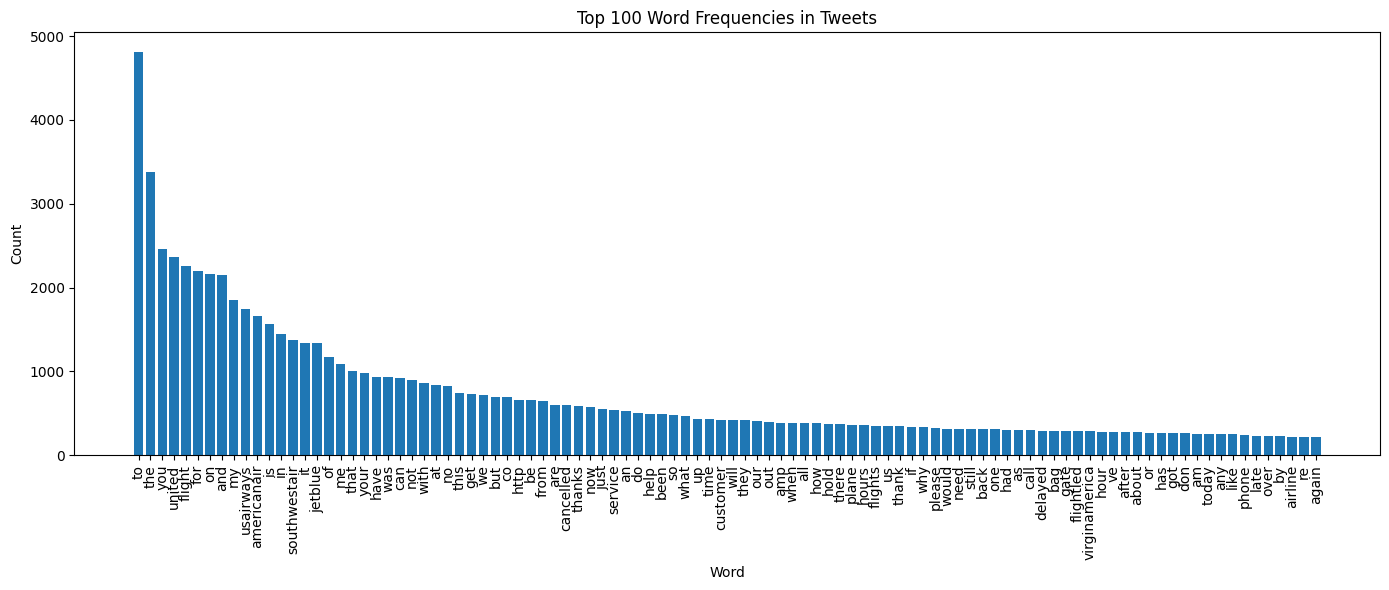

In [33]:
# exploratory visualization
word_list = top_100_counter.get_feature_names_out()
word_counts = np.asarray(X_top_100.sum(axis=0)).flatten()  # sum across rows (documents)

# Create DataFrame
word_freq = pd.DataFrame({'word': word_list, 'count': word_counts})
word_freq = word_freq.sort_values(by='count', ascending=False)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(word_freq['word'], word_freq['count'])
plt.xticks(rotation=90)
plt.title("Top 100 Word Frequencies in Tweets")
plt.xlabel("Word")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The bar chart displays the top 100 most frequently occurring words in the tweet dataset. Many of the highest-frequency terms—such as “to,” “the,” “you,” “your,” “and,” and “my”—are common English stopwords that appear in all types of tweets regardless of their sentiment. Additionally, words like “flight,” “airline,” and “customer,” while relevant to the airline domain, are too generic to effectively distinguish between positive, neutral, and negative sentiment. Including such words in the model may introduce noise and reduce classification accuracy. To improve model performance, we apply TfidfVectorizer with stop_words='english' to remove these common and non-discriminative terms. This transformation helps the model focus on more sentiment-revealing phrases—such as “delayed again,” “thank you,” or “worst experience”—which are more predictive of tweet polarity.

### Models

In [3]:
# process data for ML
# create X and y for train data
X_train = tweets_train["text"]
y_train = tweets_train["sentiment"]

# create X and y for test data
X_test = tweets_test["text"]
y_test = tweets_test["sentiment"]


In [34]:
# Pipeline with Tfidf + RandomForest
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english')),
    ('clf', RandomForestClassifier(random_state=42))
])

# Parameter grid
param_grid = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__class_weight': [
        None,
        'balanced',
        {'positive': 2, 'neutral': 1, 'negative': 0.5},
        {'positive': 1, 'neutral': 1, 'negative': 0.5}
    ]
}

# GridSearchCV
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Output best parameters
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__n_estimators': 200, 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 1)}
Best CV Score: 0.7400121432908318


In [ ]:
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # unigrams or unigrams+bigrams
    'clf__C': [0.1, 1, 10],                  # regularization strength
    'clf__penalty': ['l2'],
    'clf__class_weight': [
        'balanced',
        {'positive': 2, 'neutral': 1, 'negative': 0.5},
        {'positive': 1, 'neutral': 1, 'negative': 0.5},  # try different boost levels
    ]
}

logis = GridSearchCV(
    pipeline,
    param_grid,
    scoring='accuracy',  # or 'accuracy' or 'f1_weighted'
    cv=5,
)

# Fit on training data
logis.fit(X_train, y_train)

# Best params and score
print("Best Parameters:", logis.best_params_)
print("Best CV Score:", logis.best_score_)

Best Parameters: {'clf__C': 1, 'clf__class_weight': {'positive': 1, 'neutral': 1, 'negative': 0.5}, 'clf__penalty': 'l2', 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 1)}
Best CV Score: 0.7608986035215544


In [ ]:
from sklearn.tree import DecisionTreeClassifier


pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english')),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'tfidf__max_features': [500, 1000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'dt__max_depth': [10, 20, None],
    'dt__min_samples_split': [2, 10],
    'dt__class_weight': [
        None,
        'balanced',
        {'positive': 2, 'neutral': 1, 'negative': 0.5},
        {'positive': 1, 'neutral': 1, 'negative': 0.5}
    ]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
   
)

grid.fit(X_train, y_train)

print("Best DT Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best DT Params: {'clf__class_weight': None, 'clf__max_depth': 10, 'clf__min_samples_split': 2, 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}
Best CV Score: 0.6971463266545234


several supervised learning models were evaluated, including Logistic Regression, Random Forest, and Decision Tree. Text preprocessing was conducted using TfidfVectorizer, tune features to the top 100,1000 and 2000 weighted terms and removing common English stop words to eliminate irrelevant or low-signal tokens. GridSearchCV was employed for hyperparameter tuning with 5-fold cross-validation to optimize key model parameters such as C (regularization strength), and class_weight for Logistic Regression. Class imbalance was addressed by testing both 'balanced' and manually weighted class configurations, especially to counteract the overrepresentation of negative tweets. The model’s performance was evaluated using accuracy, recall, and confusion matrices, with emphasis on minimizing false negatives for negative tweets to ensure customer complaints are not overlooked. The final model we chose was the Logistic Regression model with a class weight of lowering the negative class by 0.5,tfidf__max_features 2000 and an ngram_range of (1, 1), which achieved the best accuracy.

## Results

In [39]:
# report model metrics
logis.score(X_test, y_test)

0.7635701275045538

The tunned logistic regression model achieved an accuracy of 0.7635 on the test set, which means the model correctly predicted the sentiment of 76.35% of the tweets.

Text(0.5, 1.0, 'Confusion Matrix')

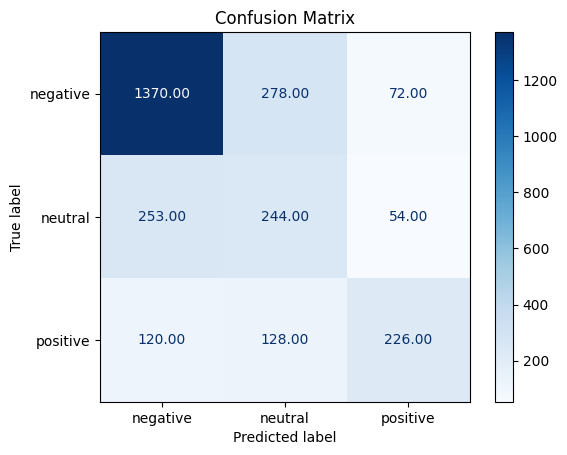

In [ ]:
# summary figure
# plot confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
y_pred = grid.predict(X_test)
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=grid.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix")

The confusion matrix reveals that the classifier performs best on the negative sentiment category, which is the most represented class in the training data. However, the model struggles more with neutral and positive tweets, frequently misclassifying them as negative. This suggests a class imbalance issue and potential overlap in the linguistic features of the neutral and positive classes.

In [77]:
# serialize model
from joblib import dump
dump(grid, "tweets.joblib")

['tweets.joblib']

## Discussion

Based on the results of our model evaluations, the selected sentiment classifier—using a TF-IDF vectorizer and a tuned Logistic Classifier—demonstrates strong alignment with the operational goals of the airline's social media team. The model performs particularly well in identifying negative tweets, which is critical for alerting customer service agents in real time. While some confusion exists between neutral and positive tweets, these errors are less impactful in practice, as they do not require urgent intervention.

The benefits of deploying the model are substantial: it automates the triage process, reduces response time, and ensures consistency across thousands of daily tweets. However, limitations remain—particularly the occasional misclassification of borderline sentiments and the underrepresentation of positive tweets in the training data. These issues can be addressed through future improvements such as rebalancing training samples, enhancing feature extraction, or integrating real-time feedback from customer service agents to refine the model iteratively.

Failing to implement the model would mean continuing to rely on manual monitoring, which is resource-intensive, inconsistent, and less scalable as tweet volume grows. Given the business-critical need for fast and accurate sentiment response, the proposed model offers a practical and effective solution that significantly enhances the team's ability to manage customer sentiment on social media platforms. However, to further improve future performance, the team should consider periodically retraining the model on newer tweets to adapt to evolving language and sentiment patterns.

Based on the reason above, we recommend deploying the model in a production environment. The model's ability to accurately classify negative tweets will enable the airline's social media team to respond promptly to customer concerns, thereby improving customer satisfaction and brand reputation. Additionally, the automation of sentiment analysis will free up valuable resources, allowing the team to focus on more complex tasks and strategic initiatives.